# Exploratory Data Analysis

 A preliminary exploratory data analysis (EDA) was conducted to understand the structure and distribution of the dataset. The dataset consists of RGB images, corresponding segmentation masks, and a captions file containing both textual descriptions and class composition percentages. Analysis of the class distributions revealed that certain land cover types, such as Grass and Crop, are more dominant, while others like Built-up and Water are less frequent, indicating a degree of class imbalance. Additionally, caption analysis showed variability in length and descriptive detail across different caption sources, suggesting that textual information may provide complementary semantic cues for the regression task.

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_ROOT = "/content/drive/MyDrive/DI725_project_dataset"
CSV_PATH = os.path.join(DATA_ROOT, "captions.csv")
IMAGE_DIR = os.path.join(DATA_ROOT, "images")
MASK_DIR = os.path.join(DATA_ROOT, "masks")

df = pd.read_csv(CSV_PATH)

print("Dataset size:", len(df))
print(df.columns)
df.head()

Dataset size: 10000
Index(['filename', 'split', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up',
       'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b',
       'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b'],
      dtype='object')


,filename,split,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,synth,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,synth,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,synth,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."
3,0172.png,synth,72,0,22,4,2,0,0,The image depicts a valley dominated by dense ...,The scene depicts a rural landscape dominated ...,"The scene is predominantly forested, with tree...",The image depicts a small town nestled within ...,This satellite image shows a small rural settl...
4,0198.png,synth,32,0,14,0,0,1,53,The image depicts a coastal area dominated by ...,The scene shows a coastal region dominated by ...,"The scene is predominantly water, covering 53%...",This image shows a coastal landscape with a na...,This satellite image shows a coastal peninsula...


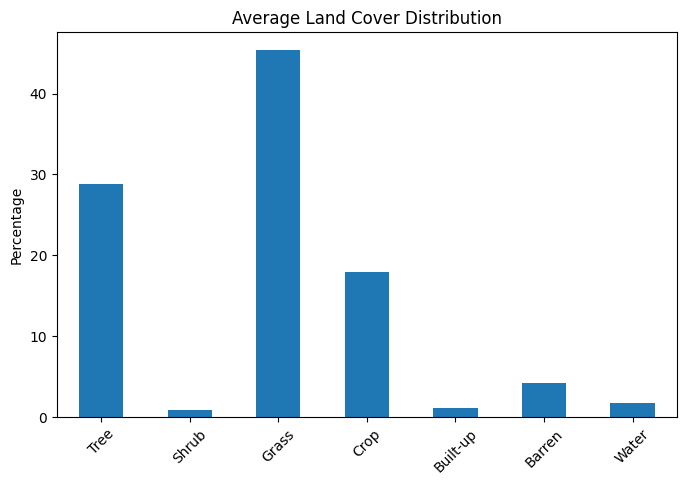

In [4]:
TARGET_COLS = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]

# Mean composition
mean_dist = df[TARGET_COLS].mean()

plt.figure(figsize=(8,5))
mean_dist.plot(kind='bar')
plt.title("Average Land Cover Distribution")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

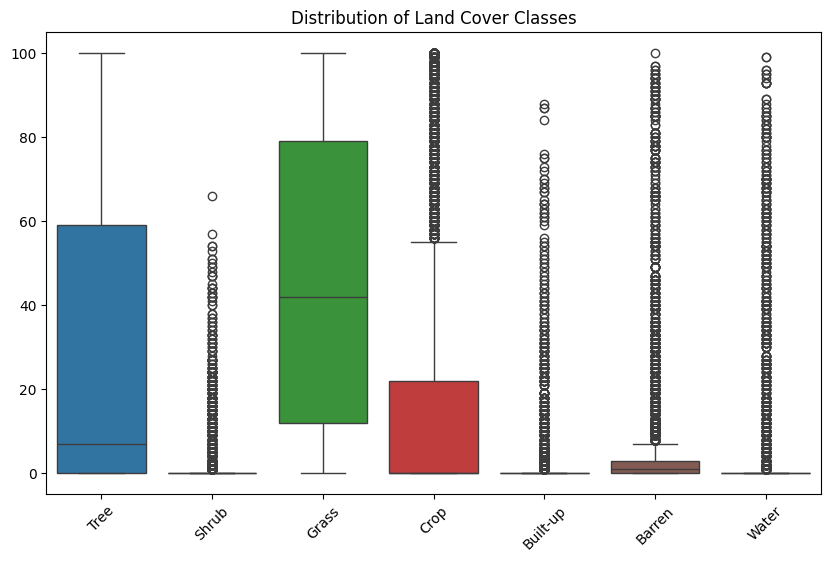

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[TARGET_COLS])
plt.title("Distribution of Land Cover Classes")
plt.xticks(rotation=45)
plt.show()

In [6]:
df["total"] = df[TARGET_COLS].sum(axis=1)

print(df["total"].describe())

count    10000.0
mean       100.0
std          0.0
min        100.0
25%        100.0
50%        100.0
75%        100.0
max        100.0
Name: total, dtype: float64


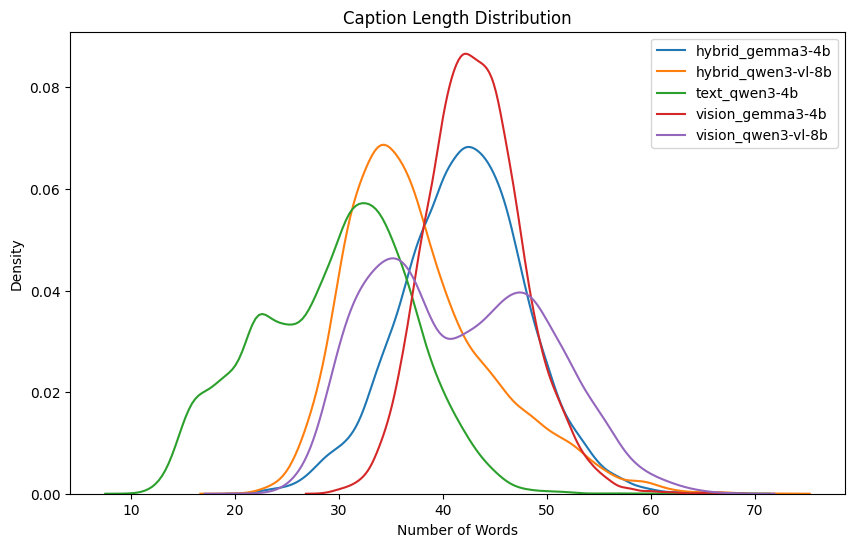

In [7]:
CAPTION_COLS = [
    "hybrid_gemma3-4b",
    "hybrid_qwen3-vl-8b",
    "text_qwen3-4b",
    "vision_gemma3-4b",
    "vision_qwen3-vl-8b"
]

for col in CAPTION_COLS:
    df[col + "_len"] = df[col].astype(str).apply(lambda x: len(x.split()))

# Plot
plt.figure(figsize=(10,6))
for col in CAPTION_COLS:
    sns.kdeplot(df[col + "_len"], label=col)

plt.legend()
plt.title("Caption Length Distribution")
plt.xlabel("Number of Words")
plt.show()

In [8]:
for col in CAPTION_COLS:
    print(f"\n--- {col} ---")
    print(df[col].iloc[0])


--- hybrid_gemma3-4b ---
The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.

--- hybrid_qwen3-vl-8b ---
The scene is dominated by grassland covering 92% of the area, with sparse, fragmented crop patches and small barren zones, suggesting a largely natural, lightly managed landscape with minor agricultural activity.

--- text_qwen3-4b ---
The scene is predominantly covered by grass, indicating a large area of natural or managed pastureland. Crop coverage is minimal, suggesting limited agricultural activity in the region.

--- vision_gemma3-4b ---
This image depicts a rugged, arid landscape characterized by extensive rocky terrain and deeply incised gullies, likely indicative of a desert or semi-arid environment with minimal vegetation cover. The dominant 

In [15]:
import os
import pandas as pd

DATA_ROOT = "/content/drive/MyDrive/DI725_project_dataset"
CSV_PATH = f"{DATA_ROOT}/captions.csv"
OUT_CSV = f"/content/drive/MyDrive/subset/captions_subset.csv"

os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)

TARGET_COLS = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]

df = pd.read_csv(CSV_PATH)

sample_df = (
    df.assign(dominant_class=df[TARGET_COLS].idxmax(axis=1))
      .groupby("dominant_class", group_keys=False)
      .apply(lambda x: x.sample(frac=500/len(df), random_state=42))
      .sample(n=500, random_state=42)
)

sample_df.to_csv(OUT_CSV, index=False)
print("Subset CSV created!")

Subset CSV created!


/tmp/ipykernel_4447/2067590085.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=500/len(df), random_state=42))


In [14]:
sample_df.to_csv(os.path.join("/content/drive/MyDrive/subset", "captions_subset.csv"), index=False)
# Compare distributions
original_mean = df[TARGET_COLS].mean()
sample_mean = sample_df[TARGET_COLS].mean()

comparison = pd.DataFrame({
    "Original": original_mean,
    "Sample": sample_mean,
    "Difference": (sample_mean - original_mean).abs()
})

print(comparison)

          Original  Sample  Difference
Tree       28.7815  27.546      1.2355
Shrub       0.8390   1.046      0.2070
Grass      45.3321  45.740      0.4079
Crop       17.9935  17.576      0.4175
Built-up    1.1402   1.046      0.0942
Barren      4.2232   5.142      0.9188
Water       1.6905   1.904      0.2135


To enable efficient experimentation under data constraints, a subset of 500 samples was created from the original dataset. A distribution aware sampling strategy was applied by grouping samples based on their dominant class and sampling proportionally from each group. This approach ensures that the subset preserves the overall class distribution of the full dataset. A comparison between the original dataset and the sampled subset shows that the differences in class wise mean percentages remain below approximately 1%, confirming that the subset is statistically representative. Therefore, the subset provides a reliable basis for evaluating model performance while reducing computational cost.